### 对已经有的环境模拟信息描述

一个市场折现率按照0.9计算里面有2个公司，市场需求函数是demand_function $100-p$ ，技术成本分别是20和10，有10个策略，
初始资金都是100，初始科技投资水平都是0，初始技术状态都是0号状态
gamma: float,
    n: int,
    demand_function: Unknown,
    c: list[Unknown],
    num_states: int,已替代
    num_actions: int,
    k0: list[Unknown],
    i: list[Unknown],
    s: list[Unknown]



In [59]:


import numpy as np
import env
import agentsnew as agents
import utili
# Create a 3D-surface GIF that cycles through each company's Q-table
import os
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import importlib
importlib.reload(env)
importlib.reload(agents)

# s1 = agents.simulate(0.1, 0.9, 0.1, 100, 1000, env.market(0.9,2, demand_function, [20,10], 10, [100,100], [0,0], [0,1]))


# 测试环境
def cournot(sc,demand_function):
    '''
    make sure demand_function is linear and decreasing.\
    Cournot competition between two firms, each firm has its own tech state and capital, but
    they share the same demand function and cost function
    
    return a list of optimal quantity for each firm
    '''
    
    cournot_matrix = np.matrix(np.eye(len(sc)) + 1)
    b = demand_function(0)
    a = b - demand_function(1)
    y = (b-np.array(sc)) / a
    
    return cournot_matrix.I @ y

def demand_function(p):
    return 100 - p

def draw_along_time(data,tag:str,exception=[],select=None,color=None):
    if select != None:
        data = data[select]
        plt.plot(data, label=f'company {select}',color=color)
    else:
        for i in range(data.shape[0]):
            if i in exception:
                continue
            plt.plot(data[i], label=f'company {i}')
    plt.xlabel('time')
    plt.ylabel(f'{tag}')
    plt.title('Value along time')
    plt.legend()
    plt.show() 


def save_along_time_pdf(data, tag, filename, exception=None, select=None, color=None):
    exception = exception or []
    fig, ax = plt.subplots(figsize=(8, 4.5))
    if select is not None:
        ax.plot(data[select], label=f'company {select}', color=color)
    else:
        for i in range(data.shape[0]):
            if i in exception:
                continue
            ax.plot(data[i], label=f'company {i}')
    ax.set_xlabel('time')
    ax.set_ylabel(tag)
    ax.set_title('Learning results')
    ax.legend()
    fig.tight_layout()
    fig.savefig(filename, format='pdf')
    plt.close(fig)


cournot([10,20],demand_function)
def eps(step,max_steps):
    return max(0.1, 0.3 - (0.2 / max_steps) * step)



In [60]:
e001 = {"No":"e001",
        "initial_capital_list": [500,100,100,100,100,100,100,100,100,100],
         "initial_tech_state_list": [0,0,0,0,0,0,0,0,0,0],
         "initial_innovation_investment_list": [0,0,0,0,0,0,0,0,0,0],
         "gamma": 0.9,
         }

e002 = {"No":"e002",
        "initial_capital_list": [1000,100,100,100,100,100,100,100,100,100],
         "initial_tech_state_list": [0,0,0,0,0,0,0,0,0,0],
         "initial_innovation_investment_list": [0,0,0,0,0,0,0,0,0,0],
         "gamma": 0.9,
         }

e003 = {"No":"e003",
        "initial_capital_list": [100,100,100,100,100,100,100,100,100,100],
         "initial_tech_state_list": [1,0,0,0,0,0,0,0,0,0],
         "initial_innovation_investment_list": [0,0,0,0,0,0,0,0,0,0],
         "gamma": 0.9,
         }
e004 = {"No":"e004",
        "initial_capital_list": [100,100,100,100,100,100,100,100,100,100],
         "initial_tech_state_list": [3,0,0,0,0,0,0,0,0,0],
         "initial_innovation_investment_list": [0,0,0,0,0,0,0,0,0,0],
         "gamma": 0.9,
         }
e005 = {"No":"e005",
        "initial_capital_list": [100,100,100,100,100,100,100,100,100,100],
         "initial_tech_state_list": [6,0,0,0,0,0,0,0,0,0],
         "initial_innovation_investment_list": [0,0,0,0,0,0,0,0,0,0],
         "gamma": 0.9,
         }
e001["initial_capital_list"]

[500, 100, 100, 100, 100, 100, 100, 100, 100, 100]

In [79]:

s001 = agents.simulate(0.1, eps, 1000, 100,
                     env.market(e001['gamma'],10, demand_function, [20,10,5,4,3,2,1], 10, e001["initial_capital_list"],
                                 e001["initial_innovation_investment_list"], e001["initial_tech_state_list"]))

s002 = agents.simulate(0.1, eps, 1000, 100,
                     env.market(e002['gamma'],10, demand_function, [20,10,5,4,3,2,1], 10, e002["initial_capital_list"],
                                 e002["initial_innovation_investment_list"], e002["initial_tech_state_list"]))
s003 = agents.simulate(0.1, eps, 1000, 100,
                     env.market(e003['gamma'],10, demand_function, [20,10,5,4,3,2,1], 10, e003["initial_capital_list"],
                                    e003["initial_innovation_investment_list"], e003["initial_tech_state_list"]))
s004 = agents.simulate(0.1, eps, 1000, 100,
                     env.market(e004['gamma'],10, demand_function, [20,10,5,4,3,2,1], 10, e004["initial_capital_list"],
                                    e004["initial_innovation_investment_list"], e004["initial_tech_state_list"]))
s005 = agents.simulate(0.1, eps, 1000, 100,
                     env.market(e005['gamma'],10, demand_function, [20,10,5,4,3,2,1], 10, e005["initial_capital_list"],
                                    e005["initial_innovation_investment_list"], e005["initial_tech_state_list"]))


In [80]:
profit,actions,Q,output,techs = s001.begin()
profit = profit.T
actions = actions.T
techs = techs.T
output = output.T
# keep original Q if needed
Q_raw = Q.copy()
# standardize each action vector: shape (company, state, action)
mean = Q.mean(axis=2, keepdims=True)
std = Q.std(axis=2, keepdims=True)

# avoid division by zero for constant vectors
Q = np.divide(Q - mean, std, out=np.zeros_like(Q), where=std > 0)

Q.shape

(10, 7, 10)

In [81]:


# If Q shape is (company, state, action) = (10, 7, 10)
assert Q.ndim == 3 and Q.shape[0] == 10 and Q.shape[1] == 7 and Q.shape[2] == 10

draw_states = np.arange(Q.shape[1])    # 0..6
draw_actions = np.arange(Q.shape[2])   # 0..9
A, S = np.meshgrid(draw_actions, draw_states)

def plot_q_surface(company_idx=0, elev=25, azim=-60):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    Z = Q[company_idx]  # (7, 10)
    surf = ax.plot_surface(A, S, Z, cmap="viridis", edgecolor="k", linewidth=0.3)

    # Control 3D camera angle
    ax.view_init(elev=elev, azim=azim)

    ax.set_xlabel("action")
    ax.set_ylabel("state")
    ax.set_zlabel("Q value")
    ax.set_title(f"Q surface - company {company_idx} | elev={elev}, azim={azim}")
    fig.colorbar(surf, ax=ax, shrink=0.65, label="Q value")
    plt.tight_layout()
    plt.show()

interact(
    plot_q_surface,
    company_idx=IntSlider(min=0, max=Q.shape[0]-1, step=1, value=0, description="company"),
    elev=IntSlider(min=-90, max=90, step=1, value=25, description="elev"),
    azim=IntSlider(min=-180, max=180, step=1, value=-60, description="azim"),
)

interactive(children=(IntSlider(value=0, description='company', max=9), IntSlider(value=25, description='elev'…

<function __main__.plot_q_surface(company_idx=0, elev=25, azim=-60)>

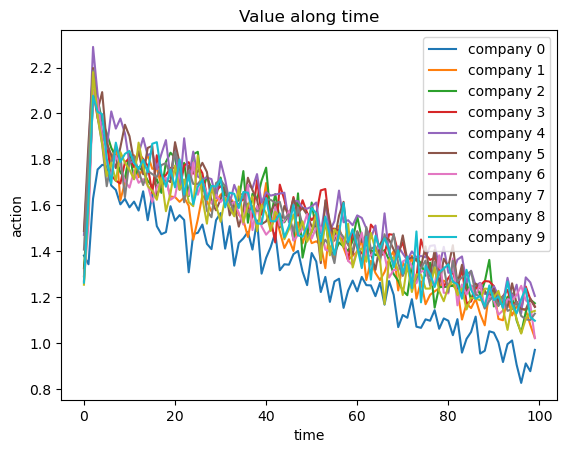

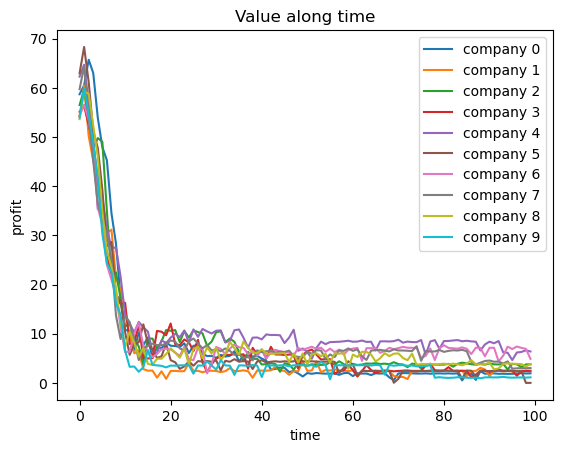

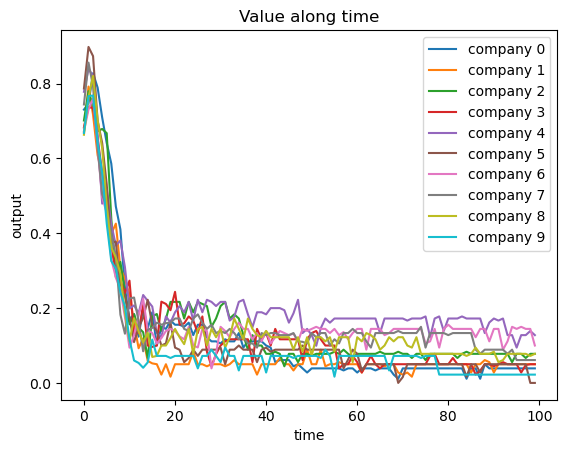

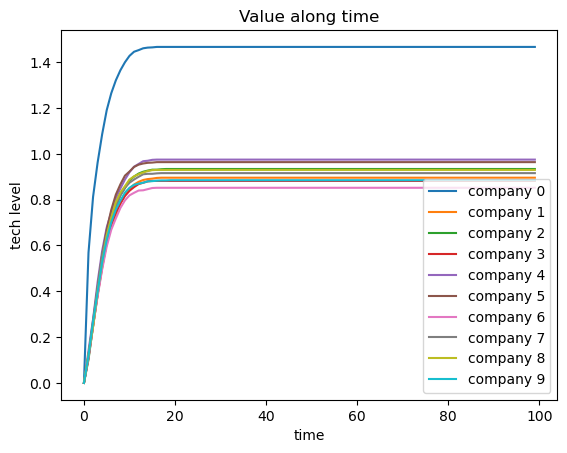

In [82]:
draw_along_time(actions,'action')
draw_along_time(profit,'profit')
draw_along_time(output,'output')
draw_along_time(techs,'tech level')

In [83]:
# save as CSV (rows=time, cols=company)
cols = ",".join([f"company_{i}" for i in range(actions.shape[1])])
np.savetxt("./v0.1innovation/e0010_actions.csv", actions, delimiter=",", header=cols, comments="", fmt="%.6f")
np.savetxt("./v0.1innovation/e0010_profit.csv", profit, delimiter=",", header=cols, comments="", fmt="%.6f")
np.savetxt("./v0.1innovation/e0010_output.csv", output.T, delimiter=",", header=cols, comments="", fmt="%.6f")
np.savetxt("./v0.1innovation/e0010_techs.csv", techs.T, delimiter=",", header=cols, comments="", fmt="%.6f")

# export all four graphs to pdf files
save_along_time_pdf(actions, 'action', './v0.1innovation/e0010_actions.pdf')
save_along_time_pdf(profit, 'profit', './v0.1innovation/e0010_profit.pdf')
save_along_time_pdf(output, 'output', './v0.1innovation/e0010_output.pdf')
save_along_time_pdf(techs, 'tech level', './v0.1innovation/e0010_tech_level.pdf')

# 2 -> 3 3 -> 4

In [ ]:
# draw_along_time(actions,'actions',select=0)
draw_along_time(techs,'tech level',select=0)

draw_along_time(techs,'tech level',select=1)

In [ ]:
from functools import wraps

# Decorator: takes a function and returns a wrapped version
def log_and_time(func):
    @wraps(func)  # keeps original function name/docstring
    def wrapper(*args, **kwargs):
        import time
        start = time.perf_counter()
        print(f"[LOG] Calling {func.__name__} args={args}, kwargs={kwargs}")
        result = func(*args, **kwargs)  # call original function
        elapsed = time.perf_counter() - start
        print(f"[LOG] {func.__name__} finished in {elapsed:.6f}s, result={result}")
        return result
    return wrapper

@log_and_time
def add(a, b):
    return a + b

value = add(3, 5)
print("final:", value)

In [ ]:
import numpy as np
def demand_function(p):
    return 100 - p 

In [ ]:
@log_and_time
def cournot(sc,demand_function):
    '''
    make sure demand_function is linear and decreasing.\
    Cournot competition between two firms, each firm has its own tech state and capital, but
    they share the same demand function and cost function
    
    return a list of optimal quantity for each firm
    '''
    
    cournot_matrix = np.matrix(np.eye(len(sc)) + 1)
    b = demand_function(0)
    a = b - demand_function(1)
    y = (b-np.array(sc)) / a
    
    return cournot_matrix.I @ y
cournot([10,20],demand_function)

In [ ]:
@log_and_time



cournot = log_and_time(cournot)

In [84]:
# # Use raw Q if available, otherwise fallback to current Q
# Q_for_gif = Q_raw if 'Q_raw' in globals() else Q
Q_for_gif = Q

if Q_for_gif.ndim != 3:
    raise ValueError(f"Expected Q shape (company, state, action), got {Q_for_gif.shape}")

num_companies, num_states, num_actions = Q_for_gif.shape
actions_axis = np.arange(num_actions)
states_axis = np.arange(num_states)
A, S = np.meshgrid(actions_axis, states_axis)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

zmin = float(np.min(Q_for_gif))
zmax = float(np.max(Q_for_gif))
if np.isclose(zmin, zmax):
    zmin -= 1.0
    zmax += 1.0

ax.set_xlabel('Action')
ax.set_ylabel('State')
ax.set_zlabel('Q value')
ax.set_zlim(zmin, zmax)
ax.view_init(elev=25, azim=-60)

def update(frame_idx):
    ax.clear()
    Z = Q_for_gif[frame_idx]
    surf = ax.plot_surface(A, S, Z, cmap='viridis', edgecolor='k', linewidth=0.25, antialiased=True)
    ax.set_xlabel('Action')

    # transparent background
    fig.patch.set_alpha(0.0)
    ax.set_facecolor((1, 1, 1, 0))

    # transparent 3D panes
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.set_ylabel('State')
    ax.set_zlabel('Q value')
    ax.set_zlim(zmin, zmax)
    ax.view_init(elev=20, azim=-121)
    ax.set_title(f'Q-table 3D Surface | Company {frame_idx}')
    return [surf]

ani = FuncAnimation(
    fig,
    update,
    frames=num_companies,
    interval=1000,
    blit=False,
    repeat=True,
    repeat_delay=1000,
 )

os.makedirs('assets', exist_ok=True)
gif_path = 'assets/q_table_companies_3d.gif'
ani.save(gif_path, writer=PillowWriter(fps=1))
plt.close(fig)

print(f'Saved GIF: {gif_path}')

Saved GIF: assets/q_table_companies_3d.gif
